In [1]:
import pandas as pd
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


data = fetch_openml(data_id=41554, as_frame=True)
df = data.frame

In [2]:
print(df.head())
print(df.describe())
print(df.info())

    Xloc   Yloc  Landuse_1  Landuse_2  Landuse_3  Landuse_4  Rock_1  Rock_2  \
0  2.386  3.077          0          0          1          0       0       0   
1  2.544  1.972          0          1          0          0       0       1   
2  2.807  3.347          0          1          0          0       0       0   
3  4.308  1.933          0          0          1          0       0       1   
4  4.383  1.081          0          0          1          0       0       0   

   Rock_3  Rock_4  Rock_5     Cr     Ni     Pb     Zn     Cd     Co     Cu  
0       1       0       0  38.32  21.32  77.36  92.56  1.740   9.32  25.72  
1       0       0       0  40.20  29.72  77.88  73.56  1.335  10.00  24.76  
2       1       0       0  47.00  21.40  30.80  64.80  1.610  10.60   8.88  
3       0       0       0  43.52  29.72  56.40  90.00  2.150  11.92  22.70  
4       0       0       1  38.52  26.20  66.40  88.40  1.565  16.32  34.32  
             Xloc        Yloc   Landuse_1   Landuse_2   Landuse

In [3]:
print(df.columns)

Index(['Xloc', 'Yloc', 'Landuse_1', 'Landuse_2', 'Landuse_3', 'Landuse_4',
       'Rock_1', 'Rock_2', 'Rock_3', 'Rock_4', 'Rock_5', 'Cr', 'Ni', 'Pb',
       'Zn', 'Cd', 'Co', 'Cu'],
      dtype='str')


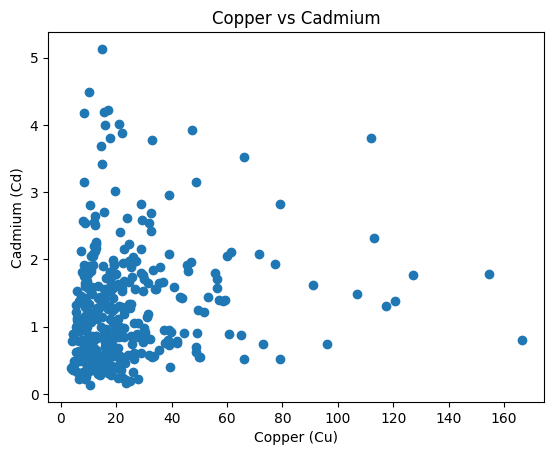

In [4]:
plt.scatter(df['Cu'], df['Cd'])
plt.xlabel("Copper (Cu)")
plt.ylabel("Cadmium (Cd)")
plt.title("Copper vs Cadmium")
plt.show()

In [5]:
X = df.drop('Cd', axis=1)
y = df['Cd']

In [6]:
poly = PolynomialFeatures(degree=2)   
X_poly = poly.fit_transform(X)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [9]:

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [10]:
y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

In [11]:


def evaluate(y_test, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} RMSE:", rmse)
    print(f"{model_name} R2:", r2)
    print("------")

evaluate(y_test, y_pred_lr, "Linear")
evaluate(y_test, y_pred_ridge, "Ridge")
evaluate(y_test, y_pred_lasso, "Lasso")

Linear RMSE: 0.8328470808943265
Linear R2: -0.06897541552736675
------
Ridge RMSE: 0.5436805249582334
Ridge R2: 0.5444618700451687
------
Lasso RMSE: 0.8087172166439488
Lasso R2: -0.007930435176925155
------


In [12]:
print("Linear Coefficients:", lr.coef_)
print("Ridge Coefficients:", ridge.coef_)
print("Lasso Coefficients:", lasso.coef_)

Linear Coefficients: [-6.78232969e-13 -1.52636106e-01  4.35489373e-01  4.17901890e-02
 -6.66587332e-02  1.05519664e-02  5.58329578e-02  8.56176263e-02
  5.69267814e-02 -6.57678219e-02 -8.22630949e-03 -8.51524800e-02
  8.86594978e-01 -6.25355180e-01 -5.36648895e-01 -2.86524139e-01
  2.88164528e-01  3.81827806e-01 -1.16107267e-01  8.79875674e-02
  2.75238893e-01 -2.45799755e-01 -1.04820650e-01  2.14590718e-02
 -2.28898257e-01  1.27735788e-01  4.49287726e-02  6.22322894e-02
 -1.57998299e-01 -2.29803299e-01 -7.99946738e-01 -7.98999718e-01
  1.96001005e+00  5.32211123e-01 -2.75045908e-01 -2.25703242e-01
 -4.22650387e-03  2.17299432e-01  1.09882955e-01  2.77746390e-01
  9.48857911e-03  2.15910942e-01  2.55054165e-02 -9.88379853e-03
  1.85739321e-01 -6.56017301e-01  8.67833029e-01  5.52332928e-01
 -4.14582694e-01 -7.47936820e-01 -3.38991789e-02  4.17901890e-02
  1.52655666e-16  4.30211422e-15  2.10942375e-15  2.77796239e-02
  7.69157662e-03  6.75088490e-02 -3.30806015e-03  3.60822483e-16
 -1.

In [13]:

zero_features = np.sum(lasso.coef_ == 0)
print("Number of features reduced to zero by Lasso:", zero_features)

Number of features reduced to zero by Lasso: 171
